In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    amplitude_damping_error,
    phase_damping_error,
    depolarizing_error,
    ReadoutError
)
from qiskit import transpile

In [ ]:
def oracle_111(qc):
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)

def oracle_000(qc):
    qc.x([0,1,2])
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x([0,1,2])

def diffuser(qc):
    qc.h([0,1,2])
    qc.x([0,1,2])

    oracle_111(qc)

    qc.x([0,1,2])
    qc.h([0,1,2])

qc = QuantumCircuit(3, 3)

# Initialize uniform superposition
qc.h([0,1,2])

# Number of Grover iterations = 2
for _ in range(2):
    oracle_000(qc)
    diffuser(qc)

# Measurement
qc.measure([0,1,2], [0,1,2])

qc.draw()

sampler = Sampler()
result = sampler.run(qc,shots = 8192).result()
counts = result.quasi_dists[0]

print(counts)

# Number of qubits
n = 3

# Sort states 0 → 7
states = sorted(counts.keys())

labels = [format(s, f'0{n}b') for s in states]
values = [counts[s] for s in states]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)

plt.xlabel("Computational Basis States")
plt.ylabel("Probability")
plt.title("3-Qubit Grover Output Distribution (Target = |111⟩)")

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [29]:
noise_model = NoiseModel()

#single-qubit Errors (T1/T2)
# Amplitude damping (T1-like)
amp_error = amplitude_damping_error(0.1)

noise_model.add_all_qubit_quantum_error(
    amp_error,
    ['h', 'x']
)

# Phase damping (T2-like)
# phase_error = phase_damping_error(0.1)
# noise_model.add_all_qubit_quantum_error(
#     phase_error,
#     ['h', 'x']
# )

# # 2 qubit Errors (CX/CXX)
# cx_error = depolarizing_error(0.1, 2)

# noise_model.add_all_qubit_quantum_error(
#     cx_error,
#     ['cx']
# )

# # Measurement Errors
# readout_error = ReadoutError([
#     [0.9, 0.1],  # P(meas 0 | 0), P(1 | 0)
#     [0.1, 0.9]   # P(meas 0 | 1), P(1 | 1)
# ])

# noise_model.add_all_qubit_readout_error(readout_error)


Raw counts:
|000⟩ : 1412
|001⟩ : 492
|010⟩ : 432
|011⟩ : 343
|100⟩ : 611
|101⟩ : 324
|110⟩ : 293
|111⟩ : 189

Probabilities:
|000⟩ : 0.3447
|001⟩ : 0.1201
|010⟩ : 0.1055
|011⟩ : 0.0837
|100⟩ : 0.1492
|101⟩ : 0.0791
|110⟩ : 0.0715
|111⟩ : 0.0461


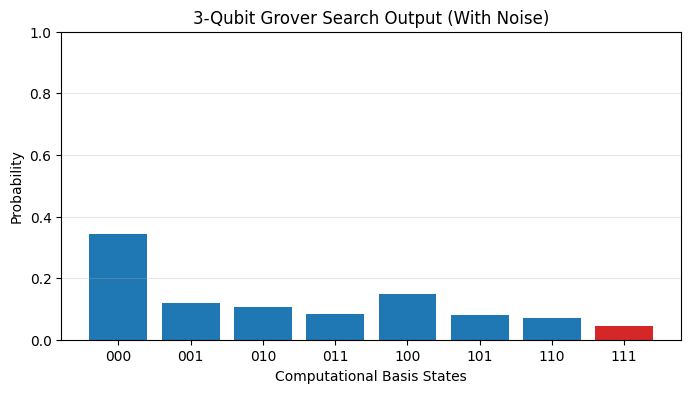

In [30]:
sim = AerSimulator(noise_model=noise_model)
# tqc = transpile(qc, sim, optimization_level=0)
shots = 4096

result_noisy = sim.run(qc, shots=4096).result()
counts_noisy = result_noisy.get_counts()

print("Raw counts:")
for state, count in sorted(counts_noisy.items()):
    print(f"|{state}⟩ : {count}")

probs_noisy = {state: count / shots for state, count in counts_noisy.items()}

print("\nProbabilities:")
for state, prob in sorted(probs_noisy.items()):
    print(f"|{state}⟩ : {prob:.4f}")


import matplotlib.pyplot as plt

# Ensure all 3-qubit basis states are present
states = [format(i, '03b') for i in range(8)]
values = [probs_noisy.get(state, 0.0) for state in states]

# Highlight the marked state |111⟩
colors = ['tab:red' if state == '111' else 'tab:blue' for state in states]

plt.figure(figsize=(8, 4))
plt.bar(states, values, color=colors)

plt.xlabel("Computational Basis States")
plt.ylabel("Probability")
plt.title("3-Qubit Grover Search Output (With Noise)")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()




#### TEST UNDER 3X GATES UNDER NOISE CONDITIONS

In [ ]:
def triple_h(qc, q):
    qc.h(q)
    qc.h(q)
    qc.h(q)

def pad_id(qc, q, n=2):
    for _ in range(n):
        qc.id(q)

def oracle_111_tripled(qc):
    triple_h(qc, 2)

    qc.ccx(0, 1, 2)
    pad_id(qc, 0)
    pad_id(qc, 1)
    pad_id(qc, 2)

    triple_h(qc, 2)


def oracle_000_tripled(qc):
    # Map |000⟩ → |111⟩
    qc.x([0, 1, 2])
    pad_id(qc, 0)
    pad_id(qc, 1)
    pad_id(qc, 2)

    # CCZ via H–CCX–H (tripled H)
    triple_h(qc, 2)
    qc.ccx(0, 1, 2)
    pad_id(qc, 0)
    pad_id(qc, 1)
    pad_id(qc, 2)
    triple_h(qc, 2)

    # Map |111⟩ → |000⟩
    qc.x([0, 1, 2])
    pad_id(qc, 0)
    pad_id(qc, 1)
    pad_id(qc, 2)

def diffuser_3q_tripled(qc):
    for q in [0, 1, 2]:
        triple_h(qc, q)

    qc.x([0, 1, 2])
    pad_id(qc, 0)
    pad_id(qc, 1)
    pad_id(qc, 2)

    triple_h(qc, 2)
    qc.ccx(0, 1, 2)
    pad_id(qc, 0)
    pad_id(qc, 1)
    pad_id(qc, 2)
    triple_h(qc, 2)

    qc.x([0, 1, 2])

    for q in [0, 1, 2]:
        triple_h(qc, q)

qc_tripled = QuantumCircuit(3, 3)

# Tripled initialization
for q in [0, 1, 2]:
    triple_h(qc_tripled, q)

for _ in range(2):
    oracle_000_tripled(qc_tripled)
    # oracle_111_tripled(qc_tripled)
    diffuser_3q_tripled(qc_tripled)

qc_tripled.measure([0, 1, 2], [0, 1, 2])
qc_tripled.draw()

#### IDEAL CONDITIONS (NO CHANGE)

{0: 0.9462890625, 1: 0.008544921875, 4: 0.0067138671875, 3: 0.0068359375, 5: 0.008056640625, 7: 0.0081787109375, 6: 0.006591796875, 2: 0.0087890625}


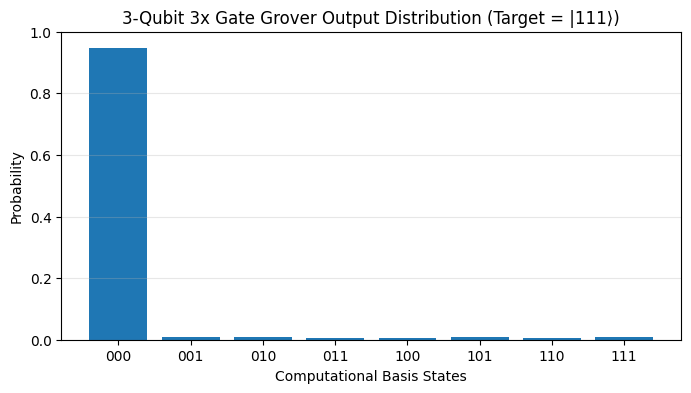

In [13]:
sampler_tripled = Sampler()
result_tripled = sampler_tripled.run(qc_tripled,shots = 8192).result()
counts_tripled = result_tripled.quasi_dists[0]

print(counts_tripled)

import matplotlib.pyplot as plt

# Number of qubits
n = 3

# Sort states 0 → 7
states = sorted(counts_tripled.keys())

labels = [format(s, f'0{n}b') for s in states]
values = [counts_tripled[s] for s in states]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)

plt.xlabel("Computational Basis States")
plt.ylabel("Probability")
plt.title("3-Qubit 3x Gate Grover Output Distribution (Target = |111⟩)")

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()


In [9]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    amplitude_damping_error,
    phase_damping_error,
    depolarizing_error,
    ReadoutError
)
from qiskit import transpile

In [14]:
noise_model = NoiseModel()

#single-qubit Errors (T1/T2)
# Amplitude damping (T1-like)
amp_error = amplitude_damping_error(0.1)

noise_model.add_all_qubit_quantum_error(
    amp_error,
    ['h', 'x']
)

# Phase damping (T2-like)
# phase_error = phase_damping_error(0.1)
# noise_model.add_all_qubit_quantum_error(
#     phase_error,
#     ['h', 'x']
# )

# # 2 qubit Errors (CX/CXX)
# cx_error = depolarizing_error(0.1, 2)

# noise_model.add_all_qubit_quantum_error(
#     cx_error,
#     ['cx']
# )

# # Measurement Errors
# readout_error = ReadoutError([
#     [0.9, 0.1],  # P(meas 0 | 0), P(1 | 0)
#     [0.1, 0.9]   # P(meas 0 | 1), P(1 | 1)
# ])

# noise_model.add_all_qubit_readout_error(readout_error)


Raw counts:
|000⟩ : 1297
|001⟩ : 520
|010⟩ : 584
|011⟩ : 324
|100⟩ : 579
|101⟩ : 292
|110⟩ : 309
|111⟩ : 191

Probabilities:
|000⟩ : 0.1583
|001⟩ : 0.0635
|010⟩ : 0.0713
|011⟩ : 0.0396
|100⟩ : 0.0707
|101⟩ : 0.0356
|110⟩ : 0.0377
|111⟩ : 0.0233


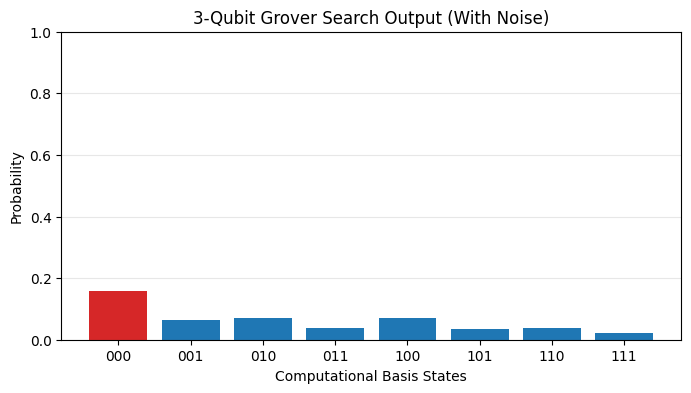

In [15]:
sim = AerSimulator(noise_model=noise_model)
# tqc = transpile(qc, sim, optimization_level=0)
shots = 8192

result_noisy_tripled = sim.run(qc_tripled, shots=4096).result()
counts_noisy_tripled = result_noisy_tripled.get_counts()

print("Raw counts:")
for state, count in sorted(counts_noisy_tripled.items()):
    print(f"|{state}⟩ : {count}")

probs_noisy_tripled = {state: count / shots for state, count in counts_noisy_tripled.items()}

print("\nProbabilities:")
for state, prob in sorted(probs_noisy_tripled.items()):
    print(f"|{state}⟩ : {prob:.4f}")


import matplotlib.pyplot as plt

# Ensure all 3-qubit basis states are present
states = [format(i, '03b') for i in range(8)]
values = [probs_noisy_tripled.get(state, 0.0) for state in states]

# Highlight the marked state |000>
colors = ['tab:red' if state == '000' else 'tab:blue' for state in states]

plt.figure(figsize=(8, 4))
plt.bar(states, values, color=colors)

plt.xlabel("Computational Basis States")
plt.ylabel("Probability")
plt.title("3-Qubit Grover Search Output (With Noise)")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()


